# 06 — Final Evaluation

**Purpose:** Evaluate all three refit models on 2026 Spring — data they have never seen.  
**Input:** Refit `.pkl` files from `models/`, `*_final.csv` files from `data/processed/`  

**Structure:**
| Block | What |
|-------|------|
| 1 | Load models + final data |
| 2 | Run all three models simultaneously |
| 3 | Standard individual metrics |
| 4 | 2025 test vs 2026 final comparison |
| 5 | System score — all three models at once (0–3) |
| 6 | Conditional evaluations — how errors cascade |
| 7 | Summary |

**Note:** 2026 Spring is one term (1,522 capacity/enrollment rows, 3,067 offered rows).  
Metrics on smaller samples are noisier — small differences from 2025 are expected.

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, confusion_matrix,
    classification_report, mean_absolute_error,
    mean_squared_error, r2_score,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA_PATH   = Path('../data/processed')
MODELS_PATH = Path('../models')
FIG_PATH    = Path('../figures/06_final_eval')
FIG_PATH.mkdir(parents=True, exist_ok=True)

# tolerance thresholds for system scoring
# a regression prediction counts as 'correct' if within ABS seats/students
# OR within REL% of actual — whichever is more lenient
CAPACITY_ABS   = 10    # seats
CAPACITY_REL   = 0.20  # 20%
ENROLLMENT_ABS = 10    # students
ENROLLMENT_REL = 0.20  # 20%

FEATURES_OFFERED = [
    'ml_course_id', 'dept_code_enc', 'degree_level_enc', 'course_level', 'units',
    'term_order', 'is_covid_affected',
    'hist_n_offerings', 'hist_n_this_semester_offerings', 'same_semester_offer_ratio',
    'n_distinct_semesters_offered', 'n_terms_since_last_offered',
    'n_consecutive_same_semester_streak',
]
FEATURES_CAPACITY = [
    'ml_course_id', 'dept_code_enc', 'degree_level_enc', 'course_level', 'units',
    'term_order', 'is_covid_affected',
    'hist_avg_capacity_per_offering', 'hist_avg_capacity_this_semester',
    'same_semester_capacity_ratio', 'previous_term_capacity',
    'previous_same_semester_capacity', 'capacity_trend',
    'hist_n_offerings', 'hist_avg_sections_per_offering',
    'hist_avg_enrollment_per_offering',
]
FEATURES_ENROLLMENT = [
    'ml_course_id', 'dept_code_enc', 'degree_level_enc', 'course_level', 'units',
    'term_order', 'is_covid_affected',
    'hist_avg_capacity_per_offering', 'hist_avg_capacity_this_semester',
    'hist_avg_enrollment_per_offering', 'hist_avg_enrollment_this_semester',
    'same_semester_enrollment_ratio', 'previous_same_semester_enrollment',
    'previous_term_enrollment', 'enrollment_trend',
    'hist_n_offerings', 'hist_avg_sections_per_offering',
    'high_fill_rate_frequency', 'prereq_count', 'course_age_terms',
]

print('ready')

ready


---
## Block 1 — Load models and final data

In [2]:
model_offered    = joblib.load(MODELS_PATH / 'model_offered.pkl')
model_capacity   = joblib.load(MODELS_PATH / 'model_capacity.pkl')
model_enrollment = joblib.load(MODELS_PATH / 'model_enrollment.pkl')
print('Models loaded.')

offered_final    = pd.read_csv(DATA_PATH / 'offered_final.csv')
capacity_final   = pd.read_csv(DATA_PATH / 'capacity_final.csv')
enrollment_final = pd.read_csv(DATA_PATH / 'enrollment_final.csv')

print(f'offered_final:    {offered_final.shape}')
print(f'capacity_final:   {capacity_final.shape}')
print(f'enrollment_final: {enrollment_final.shape}')
print()
print(f'offered positive rate:  {offered_final["offered"].mean()*100:.1f}%')
print(f'mean capacity (actual): {capacity_final["total_capacity"].mean():.1f} seats')
print(f'mean enrolled (actual): {enrollment_final["total_enrolled"].mean():.1f} students')

Models loaded.
offered_final:    (3067, 14)
capacity_final:   (1522, 18)
enrollment_final: (1522, 22)

offered positive rate:  49.6%
mean capacity (actual): 68.2 seats
mean enrolled (actual): 49.4 students


---
## Block 2 — Run all three models simultaneously

Every row gets predictions from all three models in one pass.  
Results sit alongside actuals for all downstream scoring.

In [3]:
# offered predictions
offered_final = offered_final.copy()
offered_final['pred_offered']      = model_offered.predict(offered_final[FEATURES_OFFERED])
offered_final['pred_offered_prob'] = model_offered.predict_proba(offered_final[FEATURES_OFFERED])[:, 1]

# capacity predictions — inverse transform from log space
capacity_final = capacity_final.copy()
capacity_final['pred_capacity'] = np.expm1(
    model_capacity.predict(capacity_final[FEATURES_CAPACITY])
)

# enrollment predictions — inverse transform from log space
enrollment_final = enrollment_final.copy()
enrollment_final['pred_enrollment'] = np.expm1(
    model_enrollment.predict(enrollment_final[FEATURES_ENROLLMENT])
)

print(f'Predictions generated.')
print(f'  offered:    {len(offered_final):,} rows')
print(f'  capacity:   {len(capacity_final):,} rows')
print(f'  enrollment: {len(enrollment_final):,} rows')

Predictions generated.
  offered:    3,067 rows
  capacity:   1,522 rows
  enrollment: 1,522 rows


---
## Block 3 — Standard individual metrics

In [4]:
# ── offered ───────────────────────────────────────────────────────────────
y_true_off = offered_final['offered']
y_pred_off = offered_final['pred_offered']
y_prob_off = offered_final['pred_offered_prob']

off_metrics = {
    'accuracy':  round(accuracy_score(y_true_off, y_pred_off), 4),
    'auc':       round(roc_auc_score(y_true_off, y_prob_off), 4),
    'f1':        round(f1_score(y_true_off, y_pred_off, zero_division=0), 4),
    'precision': round(precision_score(y_true_off, y_pred_off, zero_division=0), 4),
    'recall':    round(recall_score(y_true_off, y_pred_off, zero_division=0), 4),
}
print('=== OFFERED (2026 Spring) ===')
for k, v in off_metrics.items():
    print(f'  {k}: {v}')
print()
print(classification_report(y_true_off, y_pred_off, target_names=['Not offered','Offered']))

=== OFFERED (2026 Spring) ===
  accuracy: 0.7408
  auc: 0.8646
  f1: 0.7575
  precision: 0.7069
  recall: 0.816

              precision    recall  f1-score   support

 Not offered       0.79      0.67      0.72      1545
     Offered       0.71      0.82      0.76      1522

    accuracy                           0.74      3067
   macro avg       0.75      0.74      0.74      3067
weighted avg       0.75      0.74      0.74      3067



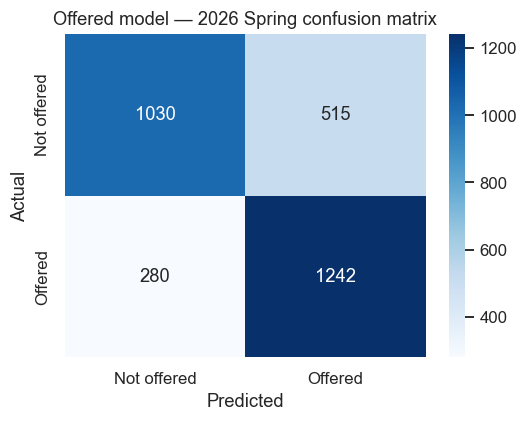

In [5]:
# confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_true_off, y_pred_off)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not offered','Offered'],
            yticklabels=['Not offered','Offered'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Offered model — 2026 Spring confusion matrix')
plt.tight_layout()
plt.savefig(FIG_PATH / 'offered_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

=== CAPACITY (2026 Spring) ===
  MAE:  14.63 seats
  RMSE: 34.10 seats
  R²:   0.8835
  Bias: -5.20 seats  (+ = overpredict)


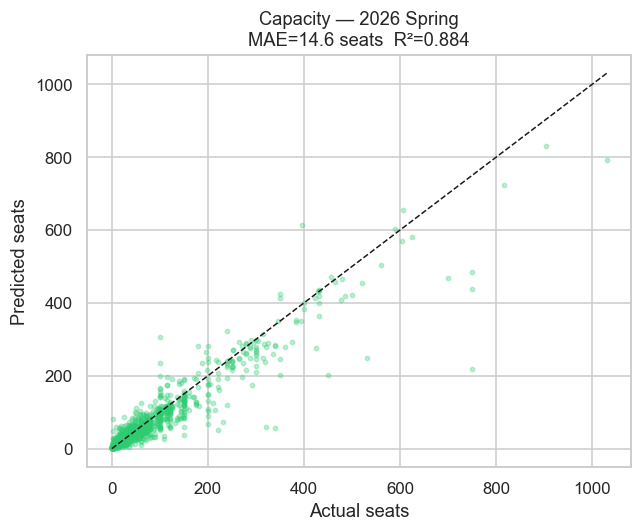

In [6]:
# ── capacity ──────────────────────────────────────────────────────────────
y_true_cap  = capacity_final['total_capacity']
y_pred_cap  = capacity_final['pred_capacity']

cap_mae  = mean_absolute_error(y_true_cap, y_pred_cap)
cap_rmse = np.sqrt(mean_squared_error(y_true_cap, y_pred_cap))
cap_r2   = r2_score(y_true_cap, y_pred_cap)
cap_bias = (y_pred_cap - y_true_cap).mean()

print('=== CAPACITY (2026 Spring) ===')
print(f'  MAE:  {cap_mae:.2f} seats')
print(f'  RMSE: {cap_rmse:.2f} seats')
print(f'  R²:   {cap_r2:.4f}')
print(f'  Bias: {cap_bias:+.2f} seats  (+ = overpredict)')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_true_cap, y_pred_cap, alpha=0.3, s=8, color='#2ecc71')
lim = max(y_true_cap.max(), y_pred_cap.max())
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlabel('Actual seats')
ax.set_ylabel('Predicted seats')
ax.set_title(f'Capacity — 2026 Spring\nMAE={cap_mae:.1f} seats  R²={cap_r2:.3f}')
plt.tight_layout()
plt.savefig(FIG_PATH / 'capacity_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

=== ENROLLMENT (2026 Spring) ===
  MAE:  11.88 students
  RMSE: 24.37 students
  R²:   0.9040
  Bias: -4.17 students  (+ = overpredict)


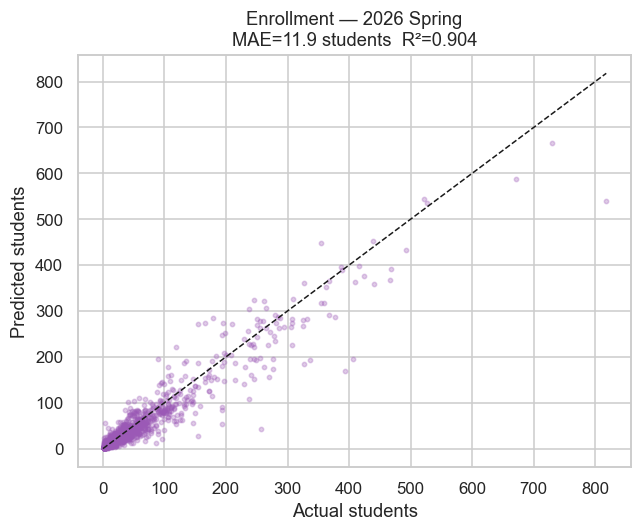

In [7]:
# ── enrollment ────────────────────────────────────────────────────────────
y_true_enr  = enrollment_final['total_enrolled']
y_pred_enr  = enrollment_final['pred_enrollment']

enr_mae  = mean_absolute_error(y_true_enr, y_pred_enr)
enr_rmse = np.sqrt(mean_squared_error(y_true_enr, y_pred_enr))
enr_r2   = r2_score(y_true_enr, y_pred_enr)
enr_bias = (y_pred_enr - y_true_enr).mean()

print('=== ENROLLMENT (2026 Spring) ===')
print(f'  MAE:  {enr_mae:.2f} students')
print(f'  RMSE: {enr_rmse:.2f} students')
print(f'  R²:   {enr_r2:.4f}')
print(f'  Bias: {enr_bias:+.2f} students  (+ = overpredict)')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_true_enr, y_pred_enr, alpha=0.3, s=8, color='#9b59b6')
lim = max(y_true_enr.max(), y_pred_enr.max())
ax.plot([0, lim], [0, lim], 'k--', lw=1)
ax.set_xlabel('Actual students')
ax.set_ylabel('Predicted students')
ax.set_title(f'Enrollment — 2026 Spring\nMAE={enr_mae:.1f} students  R²={enr_r2:.3f}')
plt.tight_layout()
plt.savefig(FIG_PATH / 'enrollment_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Block 4 — 2025 test vs 2026 final comparison

Direct comparison of selection-time performance (2025) vs final real-world performance (2026).  
If 2026 metrics are close to 2025, the models generalise well.

In [8]:
# 2025 results from 04a/04b/04c — paste from those notebooks
comparison = pd.DataFrame({
    'Model': ['Offered (GB)', 'Capacity (RF)', 'Enrollment (RF)'],
    'Metric': ['AUC', 'MAE (seats)', 'MAE (students)'],
    '2025 test': [0.9329, 14.11, 11.61],
    '2026 final': [
        round(off_metrics['auc'], 4),
        round(cap_mae, 2),
        round(enr_mae, 2),
    ]
})
comparison['Change'] = comparison['2026 final'] - comparison['2025 test']
comparison['Change'] = comparison['Change'].apply(lambda x: f'{x:+.3f}')

print('=== 2025 TEST vs 2026 FINAL ===')
print(comparison.to_string(index=False))
print()
print('For offered: lower AUC = worse. For capacity/enrollment: higher MAE = worse.')
print('Small changes are expected due to smaller sample size (1,522 vs 4,126 rows).')

=== 2025 TEST vs 2026 FINAL ===
          Model         Metric  2025 test  2026 final Change
   Offered (GB)            AUC     0.9329      0.8646 -0.068
  Capacity (RF)    MAE (seats)    14.1100     14.6300 +0.520
Enrollment (RF) MAE (students)    11.6100     11.8800 +0.270

For offered: lower AUC = worse. For capacity/enrollment: higher MAE = worse.
Small changes are expected due to smaller sample size (1,522 vs 4,126 rows).


---
## Block 5 — System score (0–3)

Score each course 0–3: +1 for each model that was correct simultaneously.  
This is what a real user experiences — partial credit for getting some predictions right.

In [9]:
# merge all predictions onto one table using ml_course_id
# only rows that appear in all three (offered=1 rows with capacity+enrollment targets)
joint = capacity_final[['ml_course_id', 'total_capacity', 'pred_capacity']].merge(
    enrollment_final[['ml_course_id', 'total_enrolled', 'pred_enrollment']],
    on='ml_course_id'
)
# add offered predictions for the same courses
joint = joint.merge(
    offered_final[offered_final['offered'] == 1][['ml_course_id', 'offered', 'pred_offered', 'pred_offered_prob']],
    on='ml_course_id'
)

print(f'Joint rows (all three scoreable): {len(joint):,}')

# score offered: exact match
joint['correct_offered'] = (joint['pred_offered'] == joint['offered']).astype(int)

# score capacity: within ABS seats OR REL% — whichever is more lenient
cap_err = (joint['pred_capacity'] - joint['total_capacity']).abs()
cap_rel = cap_err / joint['total_capacity'].replace(0, np.nan)
joint['correct_capacity'] = ((cap_err <= CAPACITY_ABS) | (cap_rel <= CAPACITY_REL)).astype(int)

# score enrollment: same logic
enr_err = (joint['pred_enrollment'] - joint['total_enrolled']).abs()
enr_rel = enr_err / joint['total_enrolled'].replace(0, np.nan)
joint['correct_enrollment'] = ((enr_err <= ENROLLMENT_ABS) | (enr_rel <= ENROLLMENT_REL)).astype(int)

# system score
joint['system_score'] = joint['correct_offered'] + joint['correct_capacity'] + joint['correct_enrollment']

print(f'\nTolerance thresholds:')
print(f'  Capacity:   within {CAPACITY_ABS} seats OR {CAPACITY_REL*100:.0f}% of actual')
print(f'  Enrollment: within {ENROLLMENT_ABS} students OR {ENROLLMENT_REL*100:.0f}% of actual')

Joint rows (all three scoreable): 1,522

Tolerance thresholds:
  Capacity:   within 10 seats OR 20% of actual
  Enrollment: within 10 students OR 20% of actual


System score distribution (2026 Spring):
  3/3 — Fully correct: 792 courses  (52.0%)
  2/3 — One wrong: 467 courses  (30.7%)
  1/3 — Two wrong: 218 courses  (14.3%)
  0/3 — All wrong: 45 courses  (3.0%)


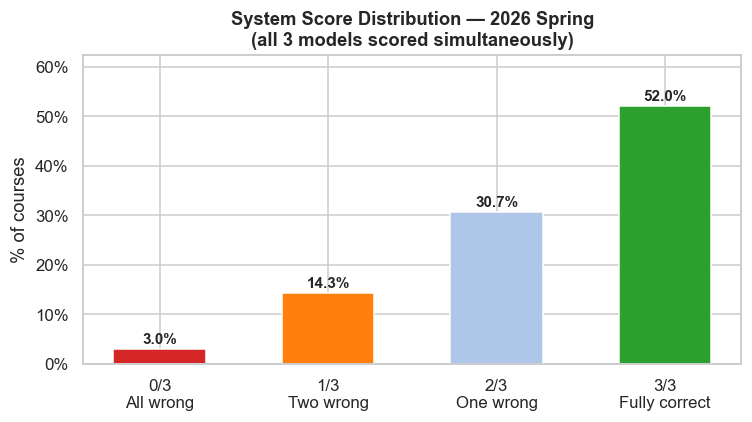

In [10]:
score_counts = joint['system_score'].value_counts().sort_index()
score_pct    = score_counts / len(joint) * 100

labels = {3: '3/3 — Fully correct', 2: '2/3 — One wrong', 1: '1/3 — Two wrong', 0: '0/3 — All wrong'}
print('System score distribution (2026 Spring):')
for score in [3, 2, 1, 0]:
    n   = score_counts.get(score, 0)
    pct = score_pct.get(score, 0)
    print(f'  {labels[score]}: {n:,} courses  ({pct:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 4))
score_labels = ['0/3\nAll wrong', '1/3\nTwo wrong', '2/3\nOne wrong', '3/3\nFully correct']
bar_colors   = ['#d62728', '#ff7f0e', '#aec7e8', '#2ca02c']
values       = [score_pct.get(s, 0) for s in [0, 1, 2, 3]]

bars = ax.bar(score_labels, values, color=bar_colors, width=0.55, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('% of courses')
ax.set_title('System Score Distribution — 2026 Spring\n(all 3 models scored simultaneously)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, max(values) * 1.2)
plt.tight_layout()
plt.savefig(FIG_PATH / 'system_score.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# which model causes the most failures?
print('Individual error rates (% of joint rows where this model was wrong):')
print(f'  Offered wrong:    {(joint["correct_offered"]==0).mean()*100:.1f}%')
print(f'  Capacity wrong:   {(joint["correct_capacity"]==0).mean()*100:.1f}%')
print(f'  Enrollment wrong: {(joint["correct_enrollment"]==0).mean()*100:.1f}%')

Individual error rates (% of joint rows where this model was wrong):
  Offered wrong:    18.4%
  Capacity wrong:   25.6%
  Enrollment wrong: 24.2%


---
## Block 6 — Conditional evaluations

How do errors cascade through the system?
- **C1** — capacity accuracy, given offered was correct
- **C2** — enrollment accuracy, given capacity was within tolerance
- **C3** — enrollment accuracy, given offered was correct

These show whether models have independent signal or whether errors compound.

In [12]:
# C1 — capacity given offered correct
c1 = joint[joint['correct_offered'] == 1]
c1_cap_acc  = c1['correct_capacity'].mean() * 100
c1_cap_mae  = (c1['pred_capacity'] - c1['total_capacity']).abs().mean()
c1_cap_bias = (c1['pred_capacity'] - c1['total_capacity']).mean()

print(f'C1 — Capacity given offered correct ({len(c1):,} rows):')
print(f'  Within tolerance: {c1_cap_acc:.1f}%')
print(f'  MAE:              {c1_cap_mae:.1f} seats')
print(f'  Bias:             {c1_cap_bias:+.1f} seats')
print()

# error buckets for capacity
cap_err_c1 = (c1['pred_capacity'] - c1['total_capacity']).abs()
print('  Capacity error buckets (given offered correct):')
for threshold in [5, 10, 20, 50]:
    pct = (cap_err_c1 <= threshold).mean() * 100
    print(f'    within {threshold:>2} seats: {pct:.1f}%')

C1 — Capacity given offered correct (1,242 rows):
  Within tolerance: 74.1%
  MAE:              15.5 seats
  Bias:             -5.1 seats

  Capacity error buckets (given offered correct):
    within  5 seats: 49.6%
    within 10 seats: 64.2%
    within 20 seats: 78.8%
    within 50 seats: 93.2%


In [13]:
# C2 — enrollment given capacity correct
c2 = joint[joint['correct_capacity'] == 1]
c2_enr_acc  = c2['correct_enrollment'].mean() * 100
c2_enr_mae  = (c2['pred_enrollment'] - c2['total_enrolled']).abs().mean()
c2_enr_bias = (c2['pred_enrollment'] - c2['total_enrolled']).mean()

print(f'C2 — Enrollment given capacity correct ({len(c2):,} rows):')
print(f'  Within tolerance: {c2_enr_acc:.1f}%')
print(f'  MAE:              {c2_enr_mae:.1f} students')
print(f'  Bias:             {c2_enr_bias:+.1f} students')
print()

# C3 — enrollment given offered correct
c3 = joint[joint['correct_offered'] == 1]
c3_enr_acc  = c3['correct_enrollment'].mean() * 100
c3_enr_mae  = (c3['pred_enrollment'] - c3['total_enrolled']).abs().mean()
c3_enr_bias = (c3['pred_enrollment'] - c3['total_enrolled']).mean()

print(f'C3 — Enrollment given offered correct ({len(c3):,} rows):')
print(f'  Within tolerance: {c3_enr_acc:.1f}%')
print(f'  MAE:              {c3_enr_mae:.1f} students')
print(f'  Bias:             {c3_enr_bias:+.1f} students')

C2 — Enrollment given capacity correct (1,132 rows):
  Within tolerance: 85.5%
  MAE:              7.8 students
  Bias:             -2.6 students

C3 — Enrollment given offered correct (1,242 rows):
  Within tolerance: 76.9%
  MAE:              12.2 students
  Bias:             -4.0 students


Enrollment accuracy summary:
  Unconditional:              75.8%
  Given offered correct (C3): 76.9%
  Given capacity correct (C2):85.5%

If C2 >> C3 >> unconditional: errors compound (capacity drives enrollment)
If all three are similar: enrollment has independent signal


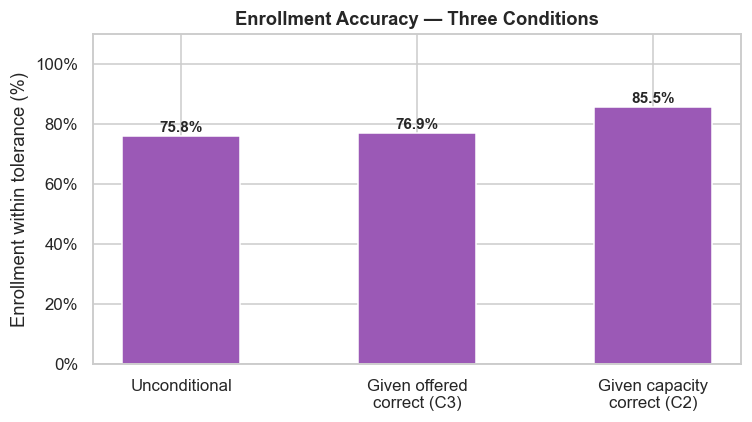

In [14]:
# enrollment accuracy — three conditions compared
enr_unconditional = joint['correct_enrollment'].mean() * 100

print('Enrollment accuracy summary:')
print(f'  Unconditional:              {enr_unconditional:.1f}%')
print(f'  Given offered correct (C3): {c3_enr_acc:.1f}%')
print(f'  Given capacity correct (C2):{c2_enr_acc:.1f}%')
print()
print('If C2 >> C3 >> unconditional: errors compound (capacity drives enrollment)')
print('If all three are similar: enrollment has independent signal')

conditions = ['Unconditional', 'Given offered\ncorrect (C3)', 'Given capacity\ncorrect (C2)']
enr_accs   = [enr_unconditional, c3_enr_acc, c2_enr_acc]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(conditions, enr_accs, color='#9b59b6', edgecolor='white', width=0.5)
for bar, val in zip(bars, enr_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Enrollment within tolerance (%)')
ax.set_title('Enrollment Accuracy — Three Conditions', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig(FIG_PATH / 'conditional_enrollment.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Block 7 — Summary

In [15]:
print('=' * 55)
print('SFU COURSE PREDICTOR — FINAL EVALUATION (2026 SPRING)')
print('=' * 55)
print()
print('INDIVIDUAL MODEL PERFORMANCE:')
print(f'  Offered    (GB)  AUC:  {off_metrics["auc"]:.4f}   Accuracy: {off_metrics["accuracy"]:.4f}')
print(f'  Capacity   (RF)  MAE:  {cap_mae:.2f} seats    R²: {cap_r2:.4f}')
print(f'  Enrollment (RF)  MAE:  {enr_mae:.2f} students  R²: {enr_r2:.4f}')
print()
print('SYSTEM PERFORMANCE (all 3 simultaneous):')
for score in [3, 2, 1, 0]:
    n   = score_counts.get(score, 0)
    pct = score_pct.get(score, 0)
    print(f'  {labels[score]}: {n:,} ({pct:.1f}%)')
print()
print('2025 TEST vs 2026 FINAL:')
print(comparison.to_string(index=False))

SFU COURSE PREDICTOR — FINAL EVALUATION (2026 SPRING)

INDIVIDUAL MODEL PERFORMANCE:
  Offered    (GB)  AUC:  0.8646   Accuracy: 0.7408
  Capacity   (RF)  MAE:  14.63 seats    R²: 0.8835
  Enrollment (RF)  MAE:  11.88 students  R²: 0.9040

SYSTEM PERFORMANCE (all 3 simultaneous):
  3/3 — Fully correct: 792 (52.0%)
  2/3 — One wrong: 467 (30.7%)
  1/3 — Two wrong: 218 (14.3%)
  0/3 — All wrong: 45 (3.0%)

2025 TEST vs 2026 FINAL:
          Model         Metric  2025 test  2026 final Change
   Offered (GB)            AUC     0.9329      0.8646 -0.068
  Capacity (RF)    MAE (seats)    14.1100     14.6300 +0.520
Enrollment (RF) MAE (students)    11.6100     11.8800 +0.270
